# Causal Inference Assignment 2
By Onno Frederik Nicolaas van der Sluijs, student no. 2065520

In [16]:
#Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "#f8fafc",
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "font.size": 12,
})

RANDOM_SEED = 2065520

#Load the dataset
df = pd.read_csv('Marketing Dataset for Individual Assignment.csv')


## Part 1 - Identification (30 points)
*Examine the DAG in Figure 1*

*1.1 For each variable in the dataset, state its causal role with respect to the effect of TV_Ad_Spend on Sales (confounder, mediator, collider, descendant of the outcome, or other — be precise). Present this as a short table. (10 pts)*

In [17]:
variables = df.columns.tolist()

table_causal_role = pd.DataFrame({
    'Variable': variables,
    'Causal Role': ['Treatment', 'Effect modifier', 'Effect modifier', 'Confounder', 'Outcome', 'Post-treatment variable', 'Collider', 'Descendant of the outcome']
})
table_causal_role.set_index('Variable', inplace=True)
table_causal_role

,Causal Role
Variable,
TV_Ad_Spend,Treatment
Radio_Ad_Spend,Effect modifier
Newspaper_Ad_Spend,Effect modifier
Market_Confidence,Confounder
Sales,Outcome
Online_Ad_Spend,Post-treatment variable
Post_Sales_Traffic,Collider
Customer_Satisfaction,Descendant of the outcome


*1.2 Based on your analysis in 1.1, state which variables you would adjust for in order to identify the causal effect of TV_Ad_Spend on Sales. Justify your choice in 4–6 sentences. Where relevant, distinguish between variables included for bias reduction and variables included for precision. (10 pts)*

In order to identify the causal effect of TV_Ad_Spend on Sales, I would adjust for Market_Confidence for bias reduction as its a confounding variable. I would also adjust for Radio_Ad_Spend and Newspaper_Ad_Spend for precision. While they are not direct confounders of the effect of TV_Ad_Spend on Sales, they are still caused by confounder Market_Confidence and their effect modifier role could introduce noise to the estimate of the causal effect of TV_Ad_Spend.

_1.3 Suppose your colleague suggests, “to be safe, let’s just include every variable in the dataset as a control.” In 4–8 sentences, explain whether this is a sound idea and why. A clear principled answer is suﬀicient; stronger answers may also check what happens empirically in this dataset and comment on any gap between the principle and what the data show. (10 pts)_

Inlcuding every variable in the dataset as a control is not a sound idea. First, not all variables are related to the effect of TV_Ad_Spend (Online_Ad_Spend and Customer_Satisfaction). Controlling for them would only introduce unnecessary bias to the treatment estimate, as they would partially absorb some of the treatments variance and make the estimate smaller than the effect is in reality. We also should not control for the collider Post_Sales_Traffic since this would add a causal path to the analysis that is not there in reality. Choosing which variables to control for should be DAG-driven rather than intuition-driven.

## Part 2 - Estimation (35 points)
*Estimate the causal effect of TV_Ad_Spend on Sales using three approaches:*
*(i) Naïve OLS — Sales regressed on TV_Ad_Spend only.*
*(ii) OLS with the controls you selected in Part 1.*
*(iii) Double Machine Learning, using the controls you selected in Part 1*

*2.1 Report all three point estimates side-by-side. For DML, also report the standard error and the 95% confidence interval. Comment briefly on the precision of the DML estimate: does the interval look like what you would expect, and what is it (and is it not) measuring? (10pts)*

In [18]:
#I noticed there were some missing values in the dataset, so I decided to drop them.
df.dropna(inplace=True)

In [19]:
#Naive OLS, Sales regressed on TV_Ad_Spend only
import statsmodels.api as sm
Y = df['Sales']
T = df['TV_Ad_Spend']
naive_ols = sm.OLS(Y, sm.add_constant(T))
naive_ols_results = naive_ols.fit()
naive_estimate = naive_ols_results.params['TV_Ad_Spend']

In [20]:
#OLS with controls I selected in Part 1
controls = ['Market_Confidence', 'Radio_Ad_Spend', 'Newspaper_Ad_Spend']

ols_with_controls = sm.OLS(df['Sales'], sm.add_constant(df[['TV_Ad_Spend'] + controls]))
ols_with_controls_results = ols_with_controls.fit()
controls_estimate = ols_with_controls_results.params['TV_Ad_Spend']

In [21]:
#Double Machine Learning with controls selected in Part 1
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
T_res = np.zeros(len(df))
Y_res = np.zeros(len(df))

X = df[controls]
y = df['Sales']
T = df['TV_Ad_Spend']

for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]

    # Fit nuisance models on training fold only
    rf_y = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=RANDOM_SEED)
    rf_t = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=RANDOM_SEED)
    rf_y.fit(X_train, Y.iloc[train_idx])
    rf_t.fit(X_train, T.iloc[train_idx])

    # Predict on held-out validation fold — genuinely out-of-sample
    Y_res[val_idx] = Y.iloc[val_idx] - rf_y.predict(X_val)
    T_res[val_idx] = T.iloc[val_idx] - rf_t.predict(X_val)

    print(f"Fold {fold+1}: val size = {len(val_idx)}, "
          f"Y R² = {1 - np.var(Y_res[val_idx])/np.var(Y.iloc[val_idx]):.3f}, "
          f"T R² = {1 - np.var(T_res[val_idx])/np.var(T.iloc[val_idx]):.3f}")

tau_dml  = (T_res @ Y_res) / (T_res @ T_res)
sigma2   = np.mean((Y_res - tau_dml * T_res)**2)
se_dml   = np.sqrt(sigma2 / np.sum(T_res**2))
ci_lo    = tau_dml - 1.96 * se_dml
ci_hi    = tau_dml + 1.96 * se_dml 

Fold 1: val size = 268, Y R² = 0.739, T R² = -0.010
Fold 2: val size = 268, Y R² = 0.742, T R² = 0.014
Fold 3: val size = 268, Y R² = 0.752, T R² = 0.048
Fold 4: val size = 268, Y R² = 0.771, T R² = 0.034
Fold 5: val size = 268, Y R² = 0.720, T R² = 0.023


In [22]:
df_estimates = pd.DataFrame({
    'Method': ['Naive OLS', 'OLS with Controls', 'Double Machine Learning'],
    'Estimate': [naive_estimate, controls_estimate, tau_dml],
    'CI Lower': [np.nan, np.nan, ci_lo],
    'CI Upper': [np.nan, np.nan, ci_hi]
})
df_estimates.set_index('Method', inplace=True)
df_estimates

,Estimate,CI Lower,CI Upper
Method,,,
Naive OLS,0.798814,NaN,NaN
OLS with Controls,0.599095,NaN,NaN
Double Machine Learning,0.606716,0.602686,0.610746


The DML estimate agrees with the OLS with confounders estimate, which is reassuring. The confidence interval of the DML estimate is very narrow. This implies that the estimate of DML is very precise given the data and model assumptions. The DML interval, being so narrow, basically measures sampling uncertainty.

*2.2 Compare the three estimates. Some will likely agree closely; others will not. In 6–10 sentences, explain what drives each agreement and each disagreement. Be specific: what is each estimator doing, and what does the pattern across the three tell you about the role of your controls and the structure of this dataset? Refer to FWL where helpful. (15 pts)*


The naive OLS estimate of 0.8 disagrees with the estimates of the other two approaches. This is expected, as it regresses Sales on TV_Ad_Spend without controlling for confounders which then bias the estimate upward. 

The OLS with controls drops the estimate to 0.60 by including those confounders as additional regressors, and by the FWL theorem, this is equivalent to regressing the residuals of Sales on the residuals of TV Ad Spend, after projecting both onto the control variables. The controlled OLS isolates the variation in TV Ad Spend that is orthogonal to the controls, and it is only that residual variation that identifies the coefficient.

The DML estimate lands at 0.60, close to the controlled OLS. DML does the same partialling-out as FWL, but uses machine learning models instead of linear projection to remove the influence of controls from both TV Ad Spend and Sales.

The drop from 0.80 to 0.60 indicates that TV_Ad_Spend is positively correlated with the controls. The agreement of controlled OLS and DML on 0.60 gives confidence that it is a robust estimate of the partial effects and suggests that the relationships between the controls and the outcome, and between the controls and the treatment, are approximately linear in this dataset.

*2.3 Of your three estimates, which would you report to the marketing director, and why? (10pts)*

I would report the DML estimate as it controls for the confounding variables, unlike the naive OLS, and it does not rely on linearity assumption, unlike the controlled OLS. Next to that it reports a tight confidence interval giving me a lot of confidence in the estimate. Overall I thus think this estimate is the most robust and defensible towards the marketing director.

## Part 3 - Diagnostics and recommendation (35pts)
*So far you have trusted the DAG. Now check it*
*3.1 Compute the pairwise correlations between all variables in the dataset and present them clearly (a heatmap or a rounded correlation table is fine). Comment briefly on anything you see that seems inconsistent with the DAG in Figure 1. (10 pts)*

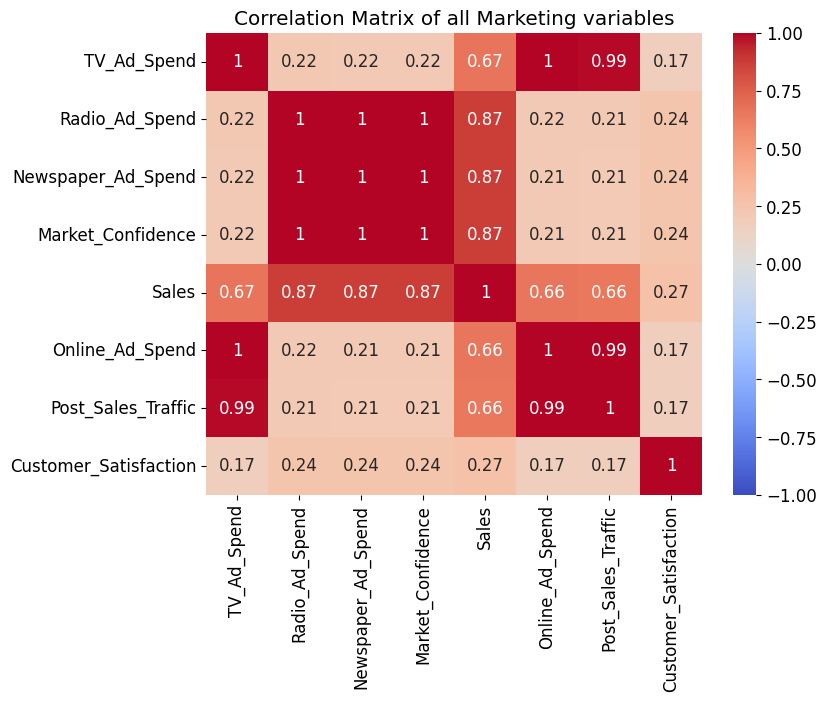

In [23]:
#Pairwise correlations between all variables in the dataset
corr_matrix = df.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix of all Marketing variables')
plt.show()

1. Radio ad spend, Newspaper ad spend and market confidence are perfectly correlated with each other. They essentially carry the same information yet are represented as separate arrows. 
2. Same for TV ad spend with Online ad spend and Post sales traffic, implying there is a much tighter relationship than just a downstream arrow.

In summary the correlation matrix thus shows that some variables, which are seen as separate consequences of each other in the DAG, are so highly correlated that the consequences are essentially unidentifiable in practice. 

*3.2 Pick the one feature of the data you find most striking in light of the DAG. State what the most likely real-world explanation is, and what — if anything — it changes about your analysis in Part 2. You will not be penalised for an interpretation we disagree with, provided it is reasoned and consistent with the data. (10 pts)*

The most striking features to me are the perfect correlation (1.00) between Radio_Ad_Spend, Newspaper_Ad_Spend, and Market_Confidence, which in the DAG play fundamentally different roles. Market_Confidence is a confounder that causes both ad spending and Sales, while Radio and Newspaper are independent ad channels with their own direct paths to Sales.

A likely real-world explanation for this is that market_confidence is a reverse-engineered feature from ad spend. Firms advertise more aggresively when they are confident in the market, and the person that made this dataset may have used that ad spending to then infer the market confidence.

This affects my analysis from Part 2. I included all three variables as a confounder. I thus added three perfectly collinear variables to control for. This does not necessarily affect the estimate, but does affect the reason why it is cleaner. It is not because I partialled out three independent confounders as the model and DAG imply, but am rather controlling for one phenomenon expressed three times. To be honest about what im actually controlling for I should replace the controls with a single composite of the three variables rather than all of them separately.

*3.3 Write a short note (max. 200 words) to the marketing director. Include: your best estimate of the effect of TV ad spend on sales, what its uncertainty means in plain language, and one substantive caveat she should know about before acting on it. No equations. No code. The audience does not know what FWL means. (15 pts)*

Dear Marketing Director,

My best estimate is that every additional euro spent on TV advertising leads to a 0.60 euro increase in Sales, after accounting for Radio and Newspaper ad channels spending, and confidence in the market. This estimate is stable across multiple analytical methods, giving me confidence it is not a statistical fluke.

The uncertainty around this number is very small. If we repeated this analysis on different samples from the same business we wuold get an estimate within 0.5 cent of 0.60 euros 95% of the time.

The caveat, though, is that TV and Online ad spend move in perfect lockstep in this data. When TV spending goes up, Online spending goes up by the same amount, every single time. This means the 0.60 estimate is really the return to increasing both together and not necessarily TV spending in isolation. If you would thus consider reallocating spending budget away from Online ads to TV ads while keeping total spending fixed, I could not tell you what would happen.

Kind regards,
Onno van der Sluijs

## Part 4 - Heterogeneity (20 points)
*Parts 1–3 estimated a single average effect. That number is correct on average and wrong for everyone individually — campaigns are deployed to specific customers and specific markets, not to averages. The marketing director will eventually want to know not only whether TV advertising lifts sales, but where it lifts them most.* 

*Extend your Part 2 analysis by fitting a Linear DML model that allows the effect of TV_Ad_Spend on Sales to vary linearly with one of the variables you adjusted for in Part 1.2. This is the simplest possible CATE model — same residualisation as Part 2(iii), with one treatment-by-covariate interaction term added to the final stage.*

*4.1 Choose one covariate from your Part 1.2 adjustment set to interact with TV_Ad_Spend.State your choice and justify it in 2–3 sentences. The justification can appeal to the DAG, to a domain story, or to a pattern you noticed in Part 3 — but not to “every variable might matter.” (5 pts)*

I pick Market_Confidence, because it represents a demand-side condition rather than a firm decision. It's interaction with TV Ad Spend asks the question: is TV advertising more effective when consumers are already predisposed to buy? This is an insight my marketing director can act on by timing TV advertisments around market sentiment. 

*Fit econml.dml.LinearDML with the chosen interaction. Then:*

*(a) Report the cate_intercept and the interaction coeﬀicient, with 95% confidence inter-vals. Use dml.summary()*

In [24]:
from econml.dml import LinearDML
X = df[['Market_Confidence']]
dml = LinearDML(model_y=RandomForestRegressor(n_estimators=200, max_depth=5, random_state=RANDOM_SEED),
                model_t=RandomForestRegressor(n_estimators=200, max_depth=5, random_state=RANDOM_SEED),
                discrete_treatment=False,
                cv=5,
                random_state=RANDOM_SEED)
dml.fit(Y, T, X=X)
dml.summary()

,point_estimate,stderr,zstat,pvalue,ci_lower,ci_upper
Market_Confidence,0.0,0.0,1.319,0.187,-0.0,0.0
,point_estimate,stderr,zstat,pvalue,ci_lower,ci_upper
cate_intercept,0.589,0.011,53.397,0.0,0.568,0.611


*(b) State in plain language what the interaction coeﬀicient means for the marketing director. A useful prompt: “For each one-unit increase in [your chosen covariate], the effect of an additional euro of TV advertising on sales changes by [value].” Spell it out at least once.*

For each one-unit increase in market confidence, the effect of an additional euro of TV advertising on sales changes by essentialy zero. The return to TV advertising does not meaningfully depend on market confidence levels. 

*(c) Compute the implied per-euro effect of TV ad spend at the 10th and 90th percentiles of your chosen covariate, and report both numbers. (10 pts)*

In [25]:
mc_10th = np.percentile(df['Market_Confidence'], 10)
mc_90th = np.percentile(df['Market_Confidence'], 90)

X_10th = np.array([[mc_10th]])
X_90th = np.array([[mc_90th]])

effect_10th = dml.effect(X_10th)[0]
effect_90th = dml.effect(X_90th)[0]

lb_10th, ub_10th = dml.effect_interval(X_10th, alpha=0.05)
lb_90th, ub_90th = dml.effect_interval(X_90th, alpha=0.05)

print(f"CATE at 10th percentile (MC={mc_10th:.2f}): {effect_10th:.3f} [{lb_10th[0]:.3f}, {ub_10th[0]:.3f}]")
print(f"CATE at 90th percentile (MC={mc_90th:.2f}): {effect_90th:.3f} [{lb_90th[0]:.3f}, {ub_90th[0]:.3f}]")

CATE at 10th percentile (MC=75.39): 0.601 [0.595, 0.607]
CATE at 90th percentile (MC=126.30): 0.608 [0.601, 0.615]


*4.3 Rewrite the manager note from 3.3 to incorporate the heterogeneity finding (max. 250 words). Same constraints as 3.3 — no equations, no code, no FWL. The note should state: your best estimate of the average effect, what its uncertainty means in plain language, the het-erogeneity finding (where the effect is larger or smaller and by how much), and one substantive caveat. (5 pts)*

Dear Marketing Director,

My best estimate is that every additional euro spent on TV advertising is associated with a 0.60 euro increase in Sales, after accounting for other ad channels and market conditions. This estimate is stable across multiple analytical methods, which gives me confidence it is not a statistical fluke. In plain terms, the uncertainty around this number is very small. If you repeated this analysis on many different samples, you would expect to get an answer very close to 0.60 almost every time.

I also investigated whether the return to TV advertising varies with market confidence. The short answer is: it does not really matter. At low market confidence (10th percentile), the estimated return is 0.601 per euro. At high market confidence (90th percentile), it is 0.608 per euro. That difference of less than one cent (0.007 euros) is negligible. There is no evidence that timing TV campaigns around periods of high consumer confidence would improve their effectiveness, and no evidence that TV underperforms when confidence is low.

The key caveat before acting on this is that TV and Online ad spend move in perfect lockstep in our data. Whenever TV ad spend increases, Online ad spend increases by the same amount every time. This means the 0.60 estimate reflects the combined return to increasing both channels together, not TV in isolation. If you are considering shifting budget between TV and Online while holding total spend fixed, this analysis cannot answer that question.

Kind regards,
Onno van der Sluijs

## AI Use Statement

I have used Github Copilot inline suggestions for coding parts of questions 3.1 and 4.1c.